In [1]:
from pathlib import Path
import random

from IPython.display import display
import numpy as np
import pandas as pd
import torch


def find_project_root(start_path: Path) -> Path:
    for candidate in (start_path.resolve(), *start_path.resolve().parents):
        has_repo_markers = (candidate / ".github").exists() or (candidate / ".git").exists()
        if has_repo_markers and (candidate / "datasets").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate the repository root from notebook working directory: {start_path}"
    )


RANDOM_SEED = 42
PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "datasets" / "postprocessed-CHEMBL379_IC50" / "scaled_dataset"
TARGET_COLUMN = "activity"
METADATA_COLUMNS = [
    "representative_molecule_chembl_id",
    "smiles",
    "canonical_smiles",
    "activity",
    "threshold_nm",
    "source_record_count",
    "source_molecule_chembl_ids",
    "source_relations",
    "source_values_nm",
    "label_sources",
    "target_chembl_id",
]

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Expected scaled dataset directory was not found: {DATA_DIR}")

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Project root: {PROJECT_ROOT}")
print(f"Scaled dataset directory: {DATA_DIR}")
print(f"Using device: {device}")

Project root: C:\Users\CaVi962\vscodeprojects\Magestic-NN
Scaled dataset directory: C:\Users\CaVi962\vscodeprojects\Magestic-NN\datasets\postprocessed-CHEMBL379_IC50\scaled_dataset
Using device: cpu


In [ ]:
RESULTS_ROOT = PROJECT_ROOT / "results" / "deep_learning_pipeline"
RESULTS_ROOT.mkdir(exist_ok=True)


def create_next_experiment_run_dir(results_root: Path) -> Path:
    experiment_indices: list[int] = []

    for candidate in results_root.iterdir():
        if not candidate.is_dir() or not candidate.name.startswith("experiment_"):
            continue

        suffix = candidate.name.removeprefix("experiment_")
        if suffix.isdigit():
            experiment_indices.append(int(suffix))

    next_index = max(experiment_indices, default=0) + 1
    return results_root / f"experiment_{next_index:03d}"


existing_run_dir = globals().get("RUN_DIR")
reuse_existing_run_dir = False

if isinstance(existing_run_dir, Path):
    try:
        reuse_existing_run_dir = (
            existing_run_dir.parent == RESULTS_ROOT
            and existing_run_dir.name.startswith("experiment_")
        )
    except OSError:
        reuse_existing_run_dir = False

if reuse_existing_run_dir:
    RUN_DIR = existing_run_dir
else:
    RUN_DIR = create_next_experiment_run_dir(RESULTS_ROOT)

HISTORY_DIR = RUN_DIR / "history"
PLOTS_DIR = RUN_DIR / "plots"

for output_dir in (RUN_DIR, HISTORY_DIR, PLOTS_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

print(f"Results root: {RESULTS_ROOT}")
print(f"Current run directory: {RUN_DIR}")
if reuse_existing_run_dir:
    print("Reusing existing run directory for this kernel session.")
else:
    print("Allocated a new run directory for this kernel session.")

Results root: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results
Current run directory: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\experiment_004
Allocated a new run directory for this kernel session.


In [3]:
train_df = pd.read_csv(DATA_DIR / "train_dataset.csv")
validation_df = pd.read_csv(DATA_DIR / "validation_dataset.csv")
test_df = pd.read_csv(DATA_DIR / "test_dataset.csv")

print("Loaded splits:")
print(f"train: {train_df.shape}")
print(f"validation: {validation_df.shape}")
print(f"test: {test_df.shape}")

Loaded splits:
train: (1686, 82)
validation: (211, 82)
test: (211, 82)


In [4]:
descriptor_columns = [
    column_name
    for column_name in train_df.columns
    if column_name not in METADATA_COLUMNS
]
validation_descriptor_columns = [
    column_name
    for column_name in validation_df.columns
    if column_name not in METADATA_COLUMNS
]
test_descriptor_columns = [
    column_name
    for column_name in test_df.columns
    if column_name not in METADATA_COLUMNS
]

assert TARGET_COLUMN in train_df.columns
assert TARGET_COLUMN in validation_df.columns
assert TARGET_COLUMN in test_df.columns
assert descriptor_columns == validation_descriptor_columns == test_descriptor_columns, (
    "Train, validation, and test splits do not share the same descriptor columns."
)
assert not train_df[descriptor_columns].isnull().any().any()
assert not validation_df[descriptor_columns].isnull().any().any()
assert not test_df[descriptor_columns].isnull().any().any()
assert set(train_df[TARGET_COLUMN].unique()) <= {0, 1}
assert set(validation_df[TARGET_COLUMN].unique()) <= {0, 1}
assert set(test_df[TARGET_COLUMN].unique()) <= {0, 1}

sanity_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(validation_df), len(test_df)],
        "active": [
            int(train_df[TARGET_COLUMN].sum()),
            int(validation_df[TARGET_COLUMN].sum()),
            int(test_df[TARGET_COLUMN].sum()),
        ],
        "inactive": [
            int((train_df[TARGET_COLUMN] == 0).sum()),
            int((validation_df[TARGET_COLUMN] == 0).sum()),
            int((test_df[TARGET_COLUMN] == 0).sum()),
        ],
    }
)

print(f"Descriptor column count: {len(descriptor_columns)}")
display(sanity_summary)

Descriptor column count: 71


,split,rows,active,inactive
0,train,1686,768,918
1,validation,211,96,115
2,test,211,96,115


In [5]:
train_metadata = train_df[METADATA_COLUMNS].copy()
validation_metadata = validation_df[METADATA_COLUMNS].copy()
test_metadata = test_df[METADATA_COLUMNS].copy()

X_train_df = train_df[descriptor_columns].copy()
X_validation_df = validation_df[descriptor_columns].copy()
X_test_df = test_df[descriptor_columns].copy()

y_train_series = train_df[TARGET_COLUMN].astype(np.float32)
y_validation_series = validation_df[TARGET_COLUMN].astype(np.float32)
y_test_series = test_df[TARGET_COLUMN].astype(np.float32)

X_train = torch.tensor(X_train_df.to_numpy(dtype=np.float32), dtype=torch.float32)
X_validation = torch.tensor(
    X_validation_df.to_numpy(dtype=np.float32),
    dtype=torch.float32,
 )
X_test = torch.tensor(X_test_df.to_numpy(dtype=np.float32), dtype=torch.float32)

y_train = torch.tensor(
    y_train_series.to_numpy(dtype=np.float32),
    dtype=torch.float32,
).unsqueeze(1)
y_validation = torch.tensor(
    y_validation_series.to_numpy(dtype=np.float32),
    dtype=torch.float32,
).unsqueeze(1)
y_test = torch.tensor(
    y_test_series.to_numpy(dtype=np.float32),
    dtype=torch.float32,
).unsqueeze(1)

print(f"X_train shape: {tuple(X_train.shape)}, y_train shape: {tuple(y_train.shape)}")
print(
    f"X_validation shape: {tuple(X_validation.shape)}, "
    f"y_validation shape: {tuple(y_validation.shape)}"
 )
print(f"X_test shape: {tuple(X_test.shape)}, y_test shape: {tuple(y_test.shape)}")

X_train shape: (1686, 71), y_train shape: (1686, 1)
X_validation shape: (211, 71), y_validation shape: (211, 1)
X_test shape: (211, 71), y_test shape: (211, 1)


In [6]:
from torch.utils.data import DataLoader, TensorDataset

TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64

train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)

sample_features, sample_targets = next(iter(train_loader))

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")
print(f"Test batches: {len(test_loader)}")
print(
    f"Sample training batch shapes: X={tuple(sample_features.shape)}, "
    f"y={tuple(sample_targets.shape)}"
 )

Train batches: 53
Validation batches: 4
Test batches: 4
Sample training batch shapes: X=(32, 71), y=(32, 1)


In [7]:
import torch.nn as nn

ARCHITECTURE_CANDIDATES = {
    "small_mlp": [32],
    "recommended_mlp": [64, 32],
    "large_mlp": [128, 64, 32],
}
DROPOUT_RATE = 0.25


class DescriptorMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], dropout: float = 0.2):
        super().__init__()

        layers: list[nn.Module] = []
        previous_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.network(inputs)


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


INPUT_DIM = X_train.shape[1]
architecture_summary = pd.DataFrame(
    [
        {
            "model": model_name,
            "hidden_layers": hidden_dims,
            "dropout": DROPOUT_RATE,
            "trainable_parameters": count_trainable_parameters(
                DescriptorMLP(INPUT_DIM, hidden_dims, dropout=DROPOUT_RATE)
            ),
        }
        for model_name, hidden_dims in ARCHITECTURE_CANDIDATES.items()
    ]
)

recommended_model = DescriptorMLP(
    INPUT_DIM,
    ARCHITECTURE_CANDIDATES["recommended_mlp"],
    dropout=DROPOUT_RATE,
).to(device)

display(architecture_summary)
print(recommended_model)

,model,hidden_layers,dropout,trainable_parameters
0,small_mlp,[32],0.25,2337
1,recommended_mlp,"[64, 32]",0.25,6721
2,large_mlp,"[128, 64, 32]",0.25,19585


DescriptorMLP(
  (network): Sequential(
    (0): Linear(in_features=71, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [8]:
from copy import deepcopy

import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tqdm import tqdm

MAX_EPOCHS = 100
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 5e-4
CLASS_LABELS = ("Inactive (0)", "Active (1)")


def reset_random_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def collect_predictions(model: nn.Module, data_loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    collected_targets = []
    collected_logits = []

    with torch.no_grad():
        for batch_features, batch_targets in data_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)
            batch_logits = model(batch_features)

            collected_targets.append(batch_targets.detach().cpu().numpy())
            collected_logits.append(batch_logits.detach().cpu().numpy())

    targets = np.vstack(collected_targets).reshape(-1)
    logits = np.vstack(collected_logits).reshape(-1)
    return targets, logits


def build_prediction_outputs(targets: np.ndarray, logits: np.ndarray) -> dict[str, np.ndarray]:
    probabilities = 1.0 / (1.0 + np.exp(-logits))
    predictions = (probabilities >= 0.5).astype(np.int64)

    return {
        "targets": targets.astype(np.int64),
        "logits": logits,
        "probabilities": probabilities,
        "predictions": predictions,
    }


def compute_binary_classification_metrics(
    targets: np.ndarray,
    logits: np.ndarray,
) -> dict[str, float]:
    prediction_outputs = build_prediction_outputs(targets, logits)
    probabilities = prediction_outputs["probabilities"]
    predictions = prediction_outputs["predictions"]

    return {
        "accuracy": float(accuracy_score(targets, predictions)),
        "precision": float(precision_score(targets, predictions, zero_division=0)),
        "recall": float(recall_score(targets, predictions, zero_division=0)),
        "f1": float(f1_score(targets, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(targets, probabilities)),
    }


def evaluate_model(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
) -> dict[str, float]:
    model.eval()
    running_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for batch_features, batch_targets in data_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)
            batch_logits = model(batch_features)
            batch_loss = loss_function(batch_logits, batch_targets)

            batch_size = batch_features.size(0)
            running_loss += batch_loss.item() * batch_size
            total_examples += batch_size

    targets, logits = collect_predictions(model, data_loader)
    metrics = compute_binary_classification_metrics(targets, logits)
    metrics["loss"] = running_loss / total_examples
    return metrics


def plot_training_history_axes(
    axes: np.ndarray,
    history_frame: pd.DataFrame,
    experiment_name: str,
) -> None:
    loss_axis, metric_axis = axes

    loss_axis.clear()
    metric_axis.clear()

    if not history_frame.empty:
        loss_axis.plot(
            history_frame["epoch"],
            history_frame["train_loss"],
            marker="o",
            label="Train loss",
        )
        loss_axis.plot(
            history_frame["epoch"],
            history_frame["validation_loss"],
            marker="o",
            label="Validation loss",
        )
        best_epoch = int(history_frame.loc[history_frame["validation_loss"].idxmin(), "epoch"])
        loss_axis.axvline(
            best_epoch,
            color="tab:gray",
            linestyle="--",
            alpha=0.5,
            label="Best validation loss",
        )

        metric_axis.plot(
            history_frame["epoch"],
            history_frame["validation_f1"],
            marker="o",
            label="Validation F1",
        )
        metric_axis.plot(
            history_frame["epoch"],
            history_frame["validation_roc_auc"],
            marker="o",
            label="Validation ROC-AUC",
        )

    loss_axis.set_title(f"{experiment_name}: train vs validation loss")
    loss_axis.set_xlabel("Epoch")
    loss_axis.set_ylabel("BCE loss")
    loss_axis.grid(True, alpha=0.3)
    loss_axis.legend()

    metric_axis.set_title(f"{experiment_name}: validation metrics")
    metric_axis.set_xlabel("Epoch")
    metric_axis.set_ylabel("Score")
    metric_axis.set_ylim(0.0, 1.0)
    metric_axis.grid(True, alpha=0.3)
    metric_axis.legend()


def create_training_history_figure(
    history_frame: pd.DataFrame,
    experiment_name: str,
) -> tuple[plt.Figure, np.ndarray]:
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_training_history_axes(axes, history_frame, experiment_name)
    figure.tight_layout()
    return figure, axes


def train_model(
    model: nn.Module,
    train_data_loader: DataLoader,
    validation_data_loader: DataLoader,
    learning_rate: float = LEARNING_RATE,
    weight_decay: float = WEIGHT_DECAY,
    max_epochs: int = MAX_EPOCHS,
    experiment_name: str = "experiment",
    show_live_dashboard: bool = True,
) -> tuple[nn.Module, pd.DataFrame, dict[str, float], int]:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    loss_function = nn.BCEWithLogitsLoss()

    best_model_state = deepcopy(model.state_dict())
    best_validation_metrics: dict[str, float] | None = None
    best_validation_loss = float("inf")
    history_rows: list[dict[str, float | int]] = []

    dashboard_figure = None
    dashboard_axes = None
    dashboard_handle = None
    if show_live_dashboard:
        dashboard_figure, dashboard_axes = create_training_history_figure(
            pd.DataFrame(),
            experiment_name,
        )
        dashboard_figure.suptitle(f"Training monitor: {experiment_name}")
        dashboard_handle = display(dashboard_figure, display_id=True)
        plt.close(dashboard_figure)

    progress_bar = tqdm(
        range(1, max_epochs + 1),
        desc=f"{experiment_name} epochs",
        leave=True,
    )

    for epoch in progress_bar:
        model.train()
        running_training_loss = 0.0
        total_training_examples = 0

        for batch_features, batch_targets in train_data_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad()
            batch_logits = model(batch_features)
            batch_loss = loss_function(batch_logits, batch_targets)
            batch_loss.backward()
            optimizer.step()

            batch_size = batch_features.size(0)
            running_training_loss += batch_loss.item() * batch_size
            total_training_examples += batch_size

        train_loss = running_training_loss / total_training_examples
        validation_metrics = evaluate_model(
            model,
            validation_data_loader,
            loss_function,
        )

        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "validation_loss": validation_metrics["loss"],
                "validation_accuracy": validation_metrics["accuracy"],
                "validation_precision": validation_metrics["precision"],
                "validation_recall": validation_metrics["recall"],
                "validation_f1": validation_metrics["f1"],
                "validation_roc_auc": validation_metrics["roc_auc"],
            }
        )

        history_frame = pd.DataFrame(history_rows)
        progress_bar.set_postfix(
            train_loss=f"{train_loss:.4f}",
            val_loss=f"{validation_metrics['loss']:.4f}",
            val_f1=f"{validation_metrics['f1']:.4f}",
        )

        if dashboard_handle is not None and dashboard_figure is not None and dashboard_axes is not None:
            plot_training_history_axes(dashboard_axes, history_frame, experiment_name)
            dashboard_figure.suptitle(f"Training monitor: {experiment_name}")
            dashboard_figure.tight_layout()
            dashboard_handle.update(dashboard_figure)

        if validation_metrics["loss"] < best_validation_loss:
            best_validation_loss = validation_metrics["loss"]
            best_validation_metrics = validation_metrics.copy()
            best_model_state = deepcopy(model.state_dict())

    progress_bar.close()

    model.load_state_dict(best_model_state)
    history_frame = pd.DataFrame(history_rows)
    if best_validation_metrics is None:
        raise RuntimeError("Training finished without recording validation metrics.")

    best_epoch = int(history_frame.loc[history_frame["validation_loss"].idxmin(), "epoch"])
    return model, history_frame, best_validation_metrics, best_epoch


def run_experiment(
    experiment_name: str,
    hidden_dims: list[int],
    dropout: float = DROPOUT_RATE,
    learning_rate: float = LEARNING_RATE,
    weight_decay: float = WEIGHT_DECAY,
    max_epochs: int = MAX_EPOCHS,
    show_live_dashboard: bool = True,
) -> dict[str, object]:
    reset_random_seed(RANDOM_SEED)
    model = DescriptorMLP(INPUT_DIM, hidden_dims, dropout=dropout).to(device)
    trained_model, history_frame, best_validation_metrics, best_epoch = train_model(
        model,
        train_loader,
        validation_loader,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        max_epochs=max_epochs,
        experiment_name=experiment_name,
        show_live_dashboard=show_live_dashboard,
    )
    loss_function = nn.BCEWithLogitsLoss()
    test_metrics = evaluate_model(trained_model, test_loader, loss_function)
    test_targets, test_logits = collect_predictions(trained_model, test_loader)
    test_outputs = build_prediction_outputs(test_targets, test_logits)
    test_confusion_matrix = confusion_matrix(
        test_outputs["targets"],
        test_outputs["predictions"],
        labels=[0, 1],
    )

    summary = pd.DataFrame(
        [
            {
                "experiment": experiment_name,
                "hidden_layers": hidden_dims,
                "dropout": dropout,
                "epochs_trained": int(history_frame["epoch"].iloc[-1]),
                "best_epoch": best_epoch,
                "validation_loss": best_validation_metrics["loss"],
                "validation_accuracy": best_validation_metrics["accuracy"],
                "validation_precision": best_validation_metrics["precision"],
                "validation_recall": best_validation_metrics["recall"],
                "validation_f1": best_validation_metrics["f1"],
                "validation_roc_auc": best_validation_metrics["roc_auc"],
                "test_loss": test_metrics["loss"],
                "test_accuracy": test_metrics["accuracy"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
                "test_f1": test_metrics["f1"],
                "test_roc_auc": test_metrics["roc_auc"],
            }
        ]
    )

    return {
        "model": trained_model,
        "history": history_frame,
        "summary": summary,
        "test_targets": test_outputs["targets"],
        "test_probabilities": test_outputs["probabilities"],
        "test_predictions": test_outputs["predictions"],
        "test_confusion_matrix": test_confusion_matrix,
    }


def build_confusion_matrix_summary(experiments: list[dict[str, object]]) -> pd.DataFrame:
    summary_rows = []

    for experiment in experiments:
        tn, fp, fn, tp = experiment["test_confusion_matrix"].ravel()
        experiment_name = str(experiment["summary"].iloc[0]["experiment"])
        summary_rows.append(
            {
                "experiment": experiment_name,
                "tn": int(tn),
                "fp": int(fp),
                "fn": int(fn),
                "tp": int(tp),
            }
        )

    return pd.DataFrame(summary_rows)


def plot_confusion_matrices(
    experiments: list[dict[str, object]],
    class_labels: tuple[str, str] = CLASS_LABELS,
) -> tuple[plt.Figure, np.ndarray]:
    if not experiments:
        raise RuntimeError(
            "No experiment results are available. Run at least one experiment cell first."
        )

    figure, axes = plt.subplots(1, len(experiments), figsize=(5 * len(experiments), 4.5))
    if len(experiments) == 1:
        axes = np.array([axes], dtype=object)

    for axis, experiment in zip(axes, experiments):
        experiment_name = str(experiment["summary"].iloc[0]["experiment"])
        matrix_display = ConfusionMatrixDisplay(
            confusion_matrix=experiment["test_confusion_matrix"],
            display_labels=list(class_labels),
        )
        matrix_display.plot(ax=axis, colorbar=False, values_format="d")
        axis.set_title(f"{experiment_name} test set")
        axis.set_xlabel("Predicted label")
        axis.set_ylabel("True label")

    figure.suptitle("Confusion matrices: rows = true labels, columns = predicted labels")
    figure.tight_layout()
    return figure, axes


print(
    "Training utilities ready. Models train for the full epoch budget and restore the best validation-loss checkpoint at the end. "
    f"Defaults: epochs={MAX_EPOCHS}, lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}"
)

Training utilities ready. Models train for the full epoch budget and restore the best validation-loss checkpoint at the end. Defaults: epochs=100, lr=0.0005, weight_decay=0.0005


C:\Users\CaVi962\AppData\Local\Temp\ipykernel_37952\3164486812.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  loss_axis.legend()
C:\Users\CaVi962\AppData\Local\Temp\ipykernel_37952\3164486812.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  metric_axis.legend()


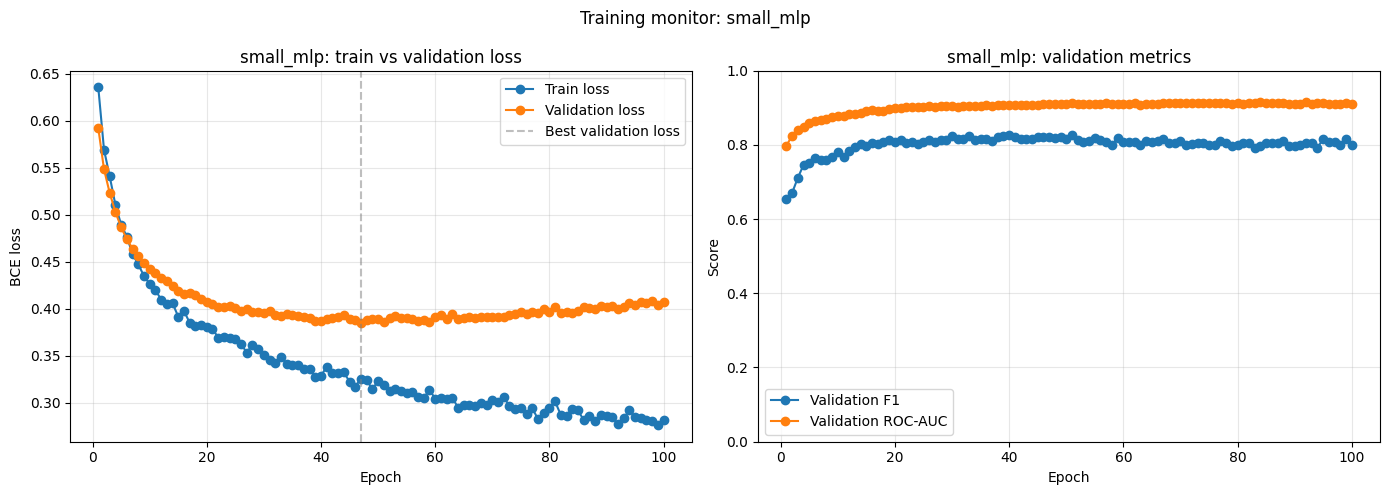

small_mlp epochs: 100%|██████████| 100/100 [00:34<00:00,  2.88it/s, train_loss=0.2812, val_f1=0.8000, val_loss=0.4071]


,experiment,hidden_layers,dropout,epochs_trained,best_epoch,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,small_mlp,[32],0.25,100,47,0.385031,0.838863,0.829787,0.8125,0.821053,0.911051,0.319668,0.85782,0.83,0.864583,0.846939,0.938451


,epoch,train_loss,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc
95,96,0.283545,0.406581,0.824645,0.810526,0.802083,0.806283,0.911141
96,97,0.282002,0.405939,0.824645,0.804124,0.812500,0.808290,0.910417
97,98,0.280795,0.408279,0.819905,0.808511,0.791667,0.800000,0.910960
98,99,0.276303,0.403536,0.834123,0.821053,0.812500,0.816754,0.913496
99,100,0.281223,0.407116,0.819905,0.808511,0.791667,0.800000,0.911322


In [9]:
small_experiment = run_experiment(
    "small_mlp",
    ARCHITECTURE_CANDIDATES["small_mlp"],
)

display(small_experiment["summary"])
display(small_experiment["history"].tail())

C:\Users\CaVi962\AppData\Local\Temp\ipykernel_37952\3164486812.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  loss_axis.legend()
C:\Users\CaVi962\AppData\Local\Temp\ipykernel_37952\3164486812.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  metric_axis.legend()


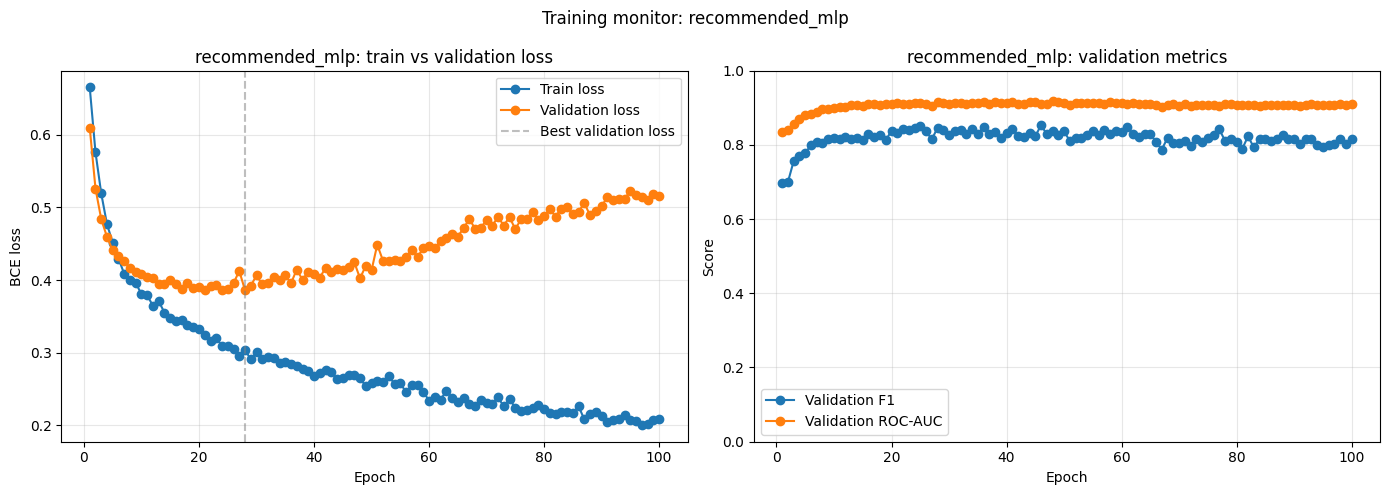

recommended_mlp epochs: 100%|██████████| 100/100 [00:36<00:00,  2.72it/s, train_loss=0.2082, val_f1=0.8168, val_loss=0.5159]


,experiment,hidden_layers,dropout,epochs_trained,best_epoch,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,recommended_mlp,"[64, 32]",0.25,100,28,0.385937,0.85782,0.836735,0.854167,0.845361,0.915761,0.320669,0.867299,0.84,0.875,0.857143,0.934647


,epoch,train_loss,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc
95,96,0.205648,0.516654,0.824645,0.831461,0.770833,0.800000,0.907563
96,97,0.200349,0.513871,0.824645,0.824176,0.781250,0.802139,0.908514
97,98,0.201779,0.510837,0.834123,0.827957,0.802083,0.814815,0.909284
98,99,0.206800,0.517880,0.824645,0.824176,0.781250,0.802139,0.907654
99,100,0.208154,0.515922,0.834123,0.821053,0.812500,0.816754,0.909737


In [10]:
recommended_experiment = run_experiment(
    "recommended_mlp",
    ARCHITECTURE_CANDIDATES["recommended_mlp"],
)

display(recommended_experiment["summary"])
display(recommended_experiment["history"].tail())

C:\Users\CaVi962\AppData\Local\Temp\ipykernel_37952\3164486812.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  loss_axis.legend()
C:\Users\CaVi962\AppData\Local\Temp\ipykernel_37952\3164486812.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  metric_axis.legend()


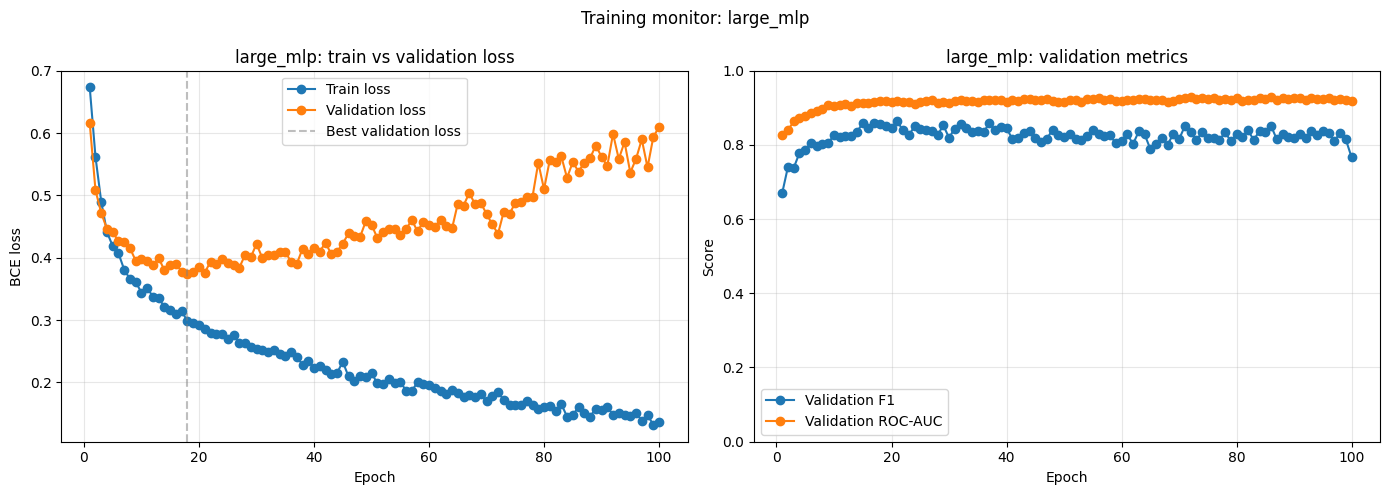

large_mlp epochs: 100%|██████████| 100/100 [00:40<00:00,  2.47it/s, train_loss=0.1368, val_f1=0.7667, val_loss=0.6101]


,experiment,hidden_layers,dropout,epochs_trained,best_epoch,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,large_mlp,"[128, 64, 32]",0.25,100,18,0.374262,0.867299,0.84,0.875,0.857143,0.91712,0.344759,0.848341,0.813725,0.864583,0.838384,0.924411


,epoch,train_loss,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc
95,96,0.151325,0.558562,0.853081,0.873563,0.791667,0.830601,0.927038
96,97,0.138434,0.589727,0.829384,0.819149,0.802083,0.810526,0.921875
97,98,0.147811,0.544821,0.848341,0.840426,0.822917,0.831579,0.923958
98,99,0.131810,0.593360,0.834123,0.827957,0.802083,0.814815,0.920245
99,100,0.136798,0.610062,0.800948,0.821429,0.718750,0.766667,0.918071


In [11]:
large_experiment = run_experiment(
    "large_mlp",
    ARCHITECTURE_CANDIDATES["large_mlp"],
)

display(large_experiment["summary"])
display(large_experiment["history"].tail())

Confusion matrices on the test set. Rows = true labels, columns = predicted labels. Class order: Inactive (0), Active (1).


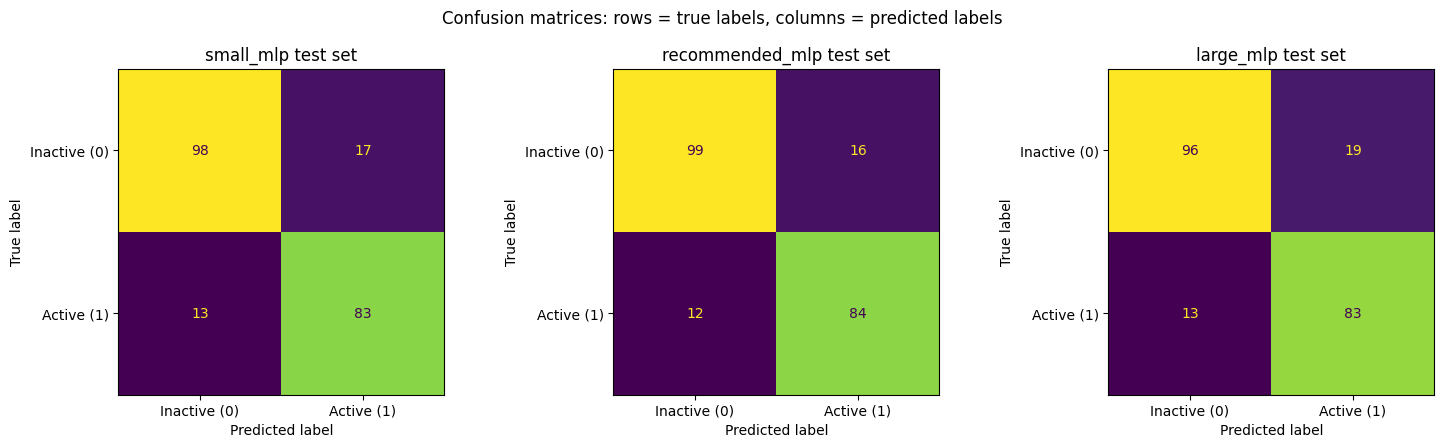

,experiment,tn,fp,fn,tp
0,small_mlp,98,17,13,83
1,recommended_mlp,99,16,12,84
2,large_mlp,96,19,13,83


In [12]:
experiment_names = [
    "small_experiment",
    "recommended_experiment",
    "large_experiment",
]

available_experiments = [
    globals()[name]
    for name in experiment_names
    if name in globals()
]

if not available_experiments:
    raise RuntimeError(
        "Run at least one experiment cell before plotting confusion matrices."
    )

print(
    "Confusion matrices on the test set. "
    "Rows = true labels, columns = predicted labels. "
    "Class order: Inactive (0), Active (1)."
 )

confusion_matrix_figure, _ = plot_confusion_matrices(available_experiments)
confusion_matrix_summary = build_confusion_matrix_summary(available_experiments)

display(confusion_matrix_figure)
display(confusion_matrix_summary)
plt.close(confusion_matrix_figure)

In [13]:
from datetime import datetime
import json

experiment_names = [
    "small_experiment",
    "recommended_experiment",
    "large_experiment",
]

available_experiments = [
    globals()[name]
    for name in experiment_names
    if name in globals()
]

if not available_experiments:
    raise RuntimeError("Run at least one experiment cell before exporting results.")

for output_dir in (RUN_DIR, HISTORY_DIR, PLOTS_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

results_summary = pd.concat(
    [experiment["summary"] for experiment in available_experiments],
    ignore_index=True,
)
confusion_matrix_summary = build_confusion_matrix_summary(available_experiments)

run_timestamp = datetime.now().isoformat(timespec="seconds")

summary_path = RUN_DIR / "summary.csv"
json_path = RUN_DIR / "summary.json"
confusion_summary_path = RUN_DIR / "test_confusion_summary.csv"

results_summary.to_csv(summary_path, index=False)
confusion_matrix_summary.to_csv(confusion_summary_path, index=False)

history_files = []
training_curve_files = []

for experiment in available_experiments:
    experiment_name = str(experiment["summary"].iloc[0]["experiment"])
    history_path = HISTORY_DIR / f"{experiment_name}_history.csv"
    training_curve_path = PLOTS_DIR / f"{experiment_name}_training_curves.png"

    experiment["history"].to_csv(history_path, index=False)

    history_figure, _ = create_training_history_figure(
        experiment["history"],
        experiment_name,
    )
    history_figure.savefig(
        training_curve_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.close(history_figure)

    history_files.append(history_path.relative_to(PROJECT_ROOT).as_posix())
    training_curve_files.append(
        training_curve_path.relative_to(PROJECT_ROOT).as_posix()
    )

confusion_matrix_path = PLOTS_DIR / "test_confusion_matrices.png"
confusion_matrix_figure, _ = plot_confusion_matrices(available_experiments)
confusion_matrix_figure.savefig(
    confusion_matrix_path,
    dpi=200,
    bbox_inches="tight",
)
plt.close(confusion_matrix_figure)

payload = {
    "run_directory": RUN_DIR.relative_to(PROJECT_ROOT).as_posix(),
    "run_timestamp": run_timestamp,
    "device": str(device),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "summary_file": summary_path.relative_to(PROJECT_ROOT).as_posix(),
    "confusion_summary_file": confusion_summary_path.relative_to(PROJECT_ROOT).as_posix(),
    "history_files": history_files,
    "training_curve_files": training_curve_files,
    "confusion_matrix_file": confusion_matrix_path.relative_to(PROJECT_ROOT).as_posix(),
    "results": results_summary.to_dict(orient="records"),
}

with json_path.open("w", encoding="utf-8") as file:
    json.dump(payload, file, indent=2)

display(results_summary)
display(confusion_matrix_summary)
print(f"Saved run directory: {RUN_DIR}")
print(f"Saved summary CSV: {summary_path}")
print(f"Saved summary JSON: {json_path}")
print(f"Saved confusion summary CSV: {confusion_summary_path}")
print(f"Saved confusion matrix figure: {confusion_matrix_path}")

,experiment,hidden_layers,dropout,epochs_trained,best_epoch,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,small_mlp,[32],0.25,100,47,0.385031,0.838863,0.829787,0.812500,0.821053,0.911051,0.319668,0.857820,0.830000,0.864583,0.846939,0.938451
1,recommended_mlp,"[64, 32]",0.25,100,28,0.385937,0.857820,0.836735,0.854167,0.845361,0.915761,0.320669,0.867299,0.840000,0.875000,0.857143,0.934647
2,large_mlp,"[128, 64, 32]",0.25,100,18,0.374262,0.867299,0.840000,0.875000,0.857143,0.917120,0.344759,0.848341,0.813725,0.864583,0.838384,0.924411


,experiment,tn,fp,fn,tp
0,small_mlp,98,17,13,83
1,recommended_mlp,99,16,12,84
2,large_mlp,96,19,13,83


Saved run directory: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\experiment_004
Saved summary CSV: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\experiment_004\summary.csv
Saved summary JSON: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\experiment_004\summary.json
Saved confusion summary CSV: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\experiment_004\test_confusion_summary.csv
Saved confusion matrix figure: C:\Users\CaVi962\vscodeprojects\Magestic-NN\results\experiment_004\plots\test_confusion_matrices.png
